# Exploratory Data Analysis

In [1]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd

import attrition_analysis.associations_test as associations_test
import attrition_analysis.data_selection as data_selection
import attrition_analysis.logistic_models_utils as logistic_models_utils
import attrition_analysis.multicollinearity as multicollinearity
import attrition_analysis.statistics_utils as statistics_utils

importlib.reload(data_selection)
importlib.reload(statistics_utils)
importlib.reload(associations_test)
importlib.reload(multicollinearity)
importlib.reload(logistic_models_utils)

from attrition_analysis.associations_test import (
    categorical_predictors_cramer_table,
    check_chi_square_assumptions,
    chi_square_table,
    cramer_table,
)
from attrition_analysis.data_selection import CATEGORICAL_MODEL_VARS, get_categorical_vars
from attrition_analysis.logistic_models_utils import (
    compare_logistic_models,
    run_logistic_models,
)
from attrition_analysis.multicollinearity import vif_categorical_table
from attrition_analysis.statistics_utils import attrition_summary

df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,EducationField,EmployeeCount,EmployeeNumber,Gender,...,IncomeGroup,EducationLevel,StockOption,JobLevelGroup,SatisfactionLevel,PerformanceRatingLevel,EnvironmentSatisfactionLevel,JobInvolvementLevel,RelationshipSatisfactionLevel,WorkLifeBalanceLevel
0,41,Yes,Travel_Rarely,1102,Sales,1,Life Sciences,1,1,Female,...,Medium,Low,No Options,Junior Level,High,Medium-High,Medium-Low,Medium-High,Low,Low
1,49,No,Travel_Frequently,279,Research & Development,8,Life Sciences,1,2,Male,...,Medium,Very Low,Low,Junior Level,Medium-Low,High,Medium-High,Medium-Low,High,Medium-High
2,37,Yes,Travel_Rarely,1373,Research & Development,2,Other,1,4,Male,...,Low,Low,No Options,Entry Level,Medium-High,Medium-High,High,Medium-Low,Medium-Low,Medium-High
3,33,No,Travel_Frequently,1392,Research & Development,3,Life Sciences,1,5,Female,...,Low,High,No Options,Entry Level,Medium-High,Medium-High,High,Medium-High,Medium-High,Medium-High
4,27,No,Travel_Rarely,591,Research & Development,2,Medical,1,7,Male,...,Medium,Very Low,Low,Entry Level,Medium-Low,Medium-High,Low,Medium-High,High,Medium-High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,Medical,1,2061,Male,...,Low,Low,Low,Junior Level,High,Medium-High,Medium-High,High,Medium-High,Medium-High
1466,39,No,Travel_Rarely,613,Research & Development,6,Medical,1,2062,Male,...,High,Very Low,Low,Mid Level,Low,Medium-High,High,Medium-Low,Low,Medium-High
1467,27,No,Travel_Rarely,155,Research & Development,4,Life Sciences,1,2064,Male,...,High,Medium,Low,Junior Level,Medium-Low,High,Medium-Low,High,Medium-Low,Medium-High
1468,49,No,Travel_Frequently,1023,Sales,2,Medical,1,2065,Male,...,Medium,Medium,No Options,Junior Level,Medium-Low,Medium-High,High,Medium-Low,High,Medium-Low


# Attrition By - Stats

In [2]:
categorical_vars = get_categorical_vars(df)

for col in categorical_vars:
    print(f'\n{col}')
    display(attrition_summary(df, col))


BusinessTravel


,BusinessTravel,total_employees,attrition_count,attrition_rate
0,Travel_Frequently,277,69,24.91
1,Travel_Rarely,1043,156,14.96
2,Non-Travel,150,12,8.00



Department


,Department,total_employees,attrition_count,attrition_rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84



EducationField


...

,JobInvolvementLevel,total_employees,attrition_count,attrition_rate
0,Low,83,28,33.73
1,Medium-Low,375,71,18.93
2,Medium-High,868,125,14.40
3,High,144,13,9.03



RelationshipSatisfactionLevel


,RelationshipSatisfactionLevel,total_employees,attrition_count,attrition_rate
0,Low,276,57,20.65
1,Medium-High,459,71,15.47
2,Medium-Low,303,45,14.85
3,High,432,64,14.81



WorkLifeBalanceLevel


,WorkLifeBalanceLevel,total_employees,attrition_count,attrition_rate
0,Low,80,25,31.25
1,High,153,27,17.65
2,Medium-Low,344,58,16.86
3,Medium-High,893,127,14.22


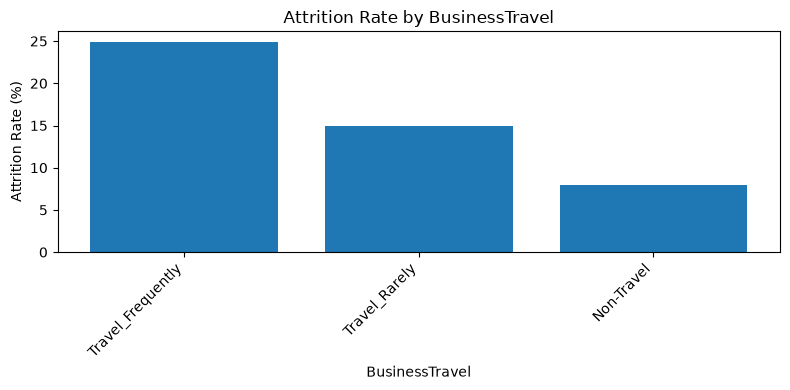

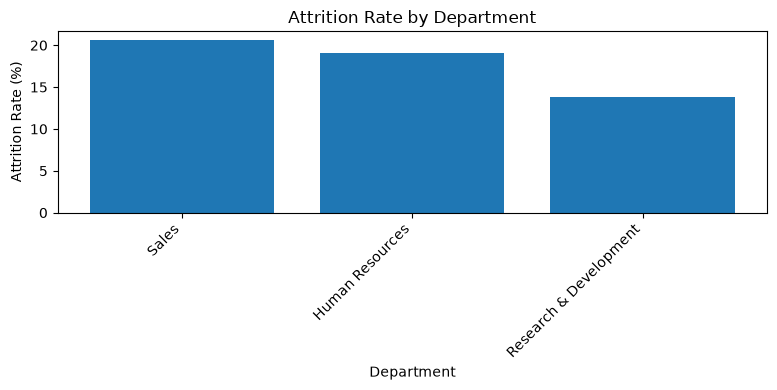

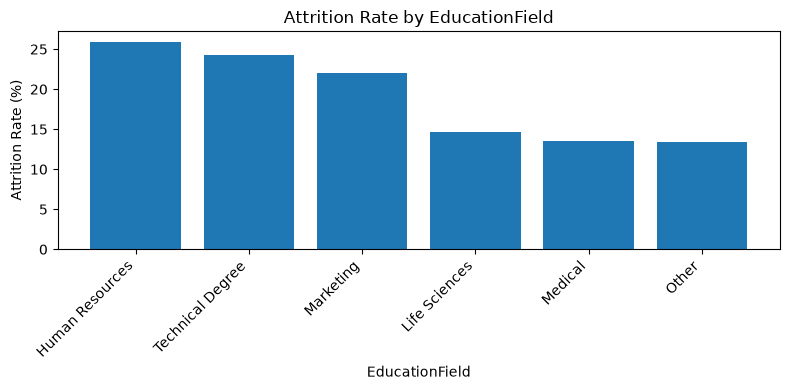

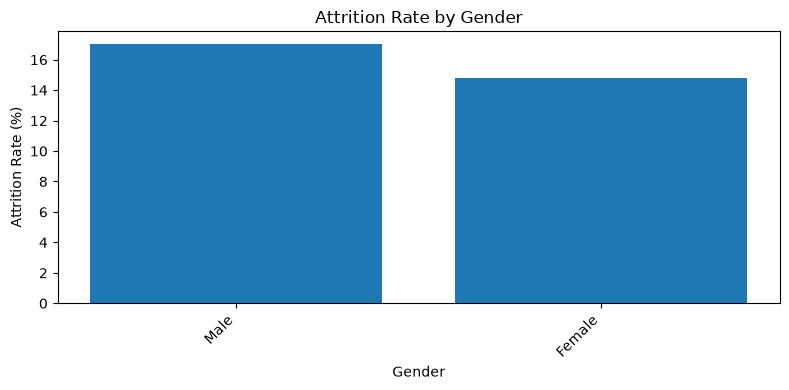

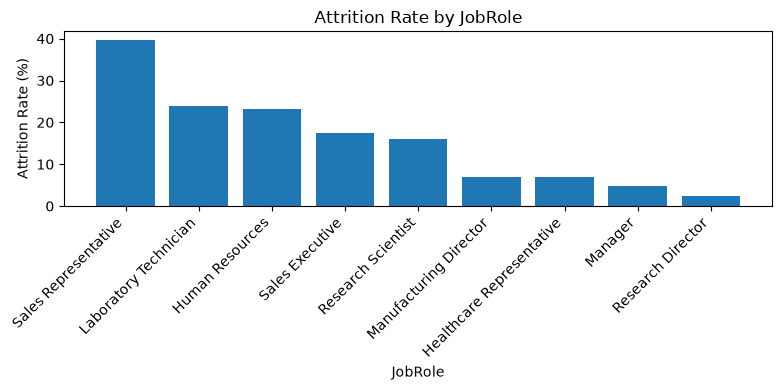

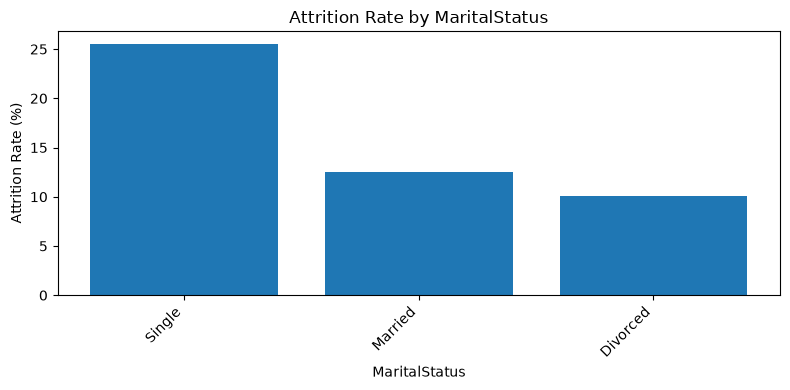

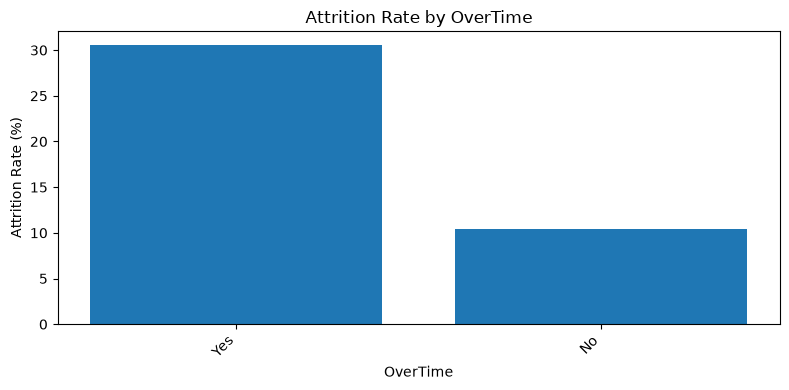

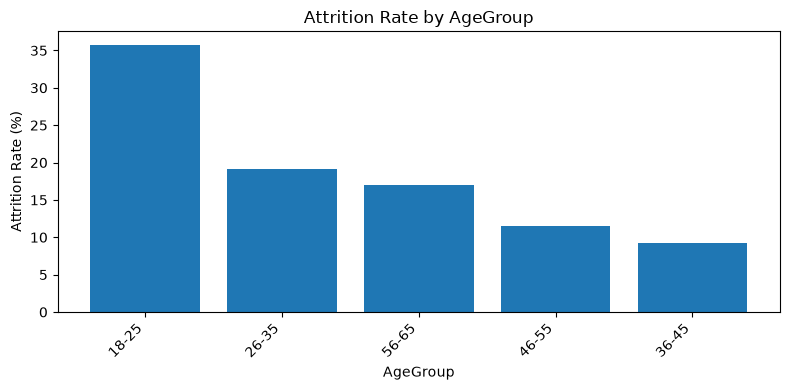

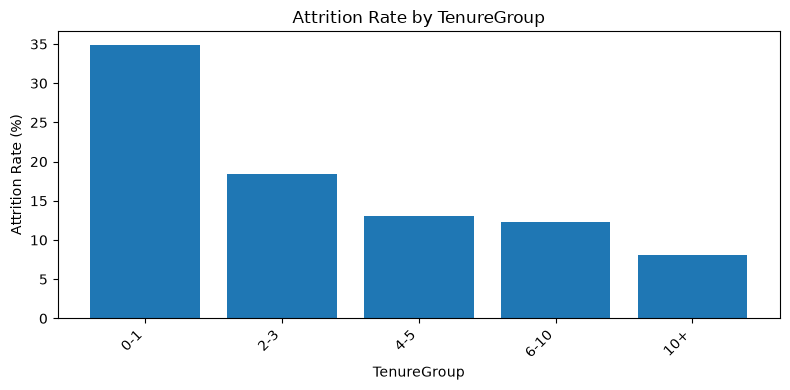

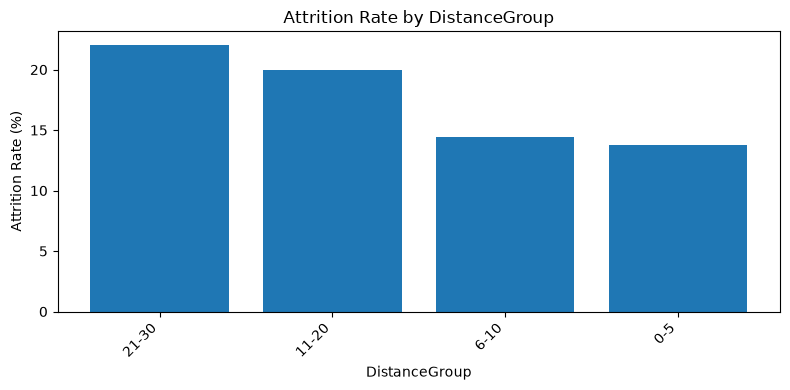

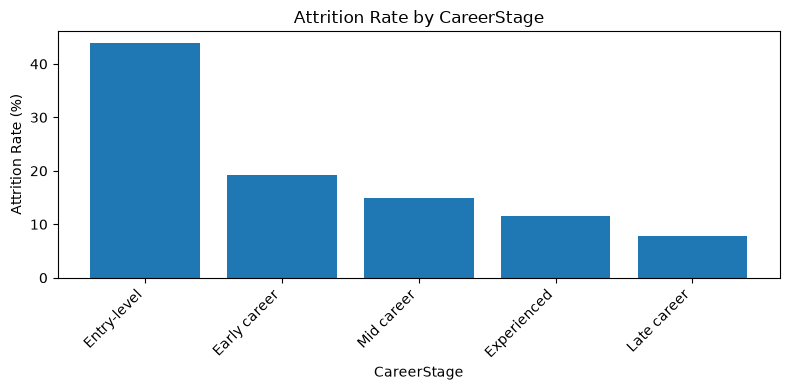

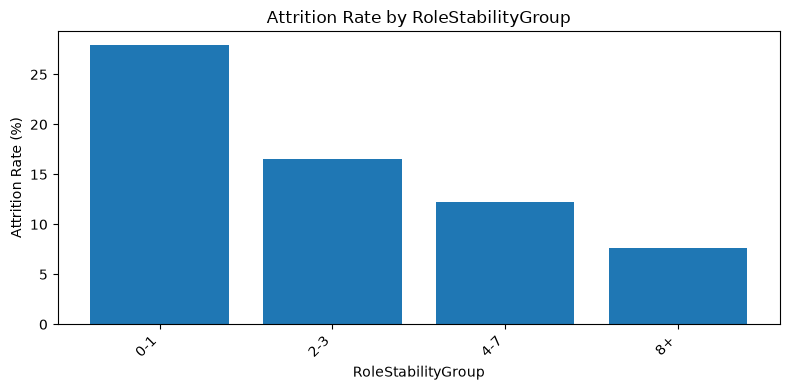

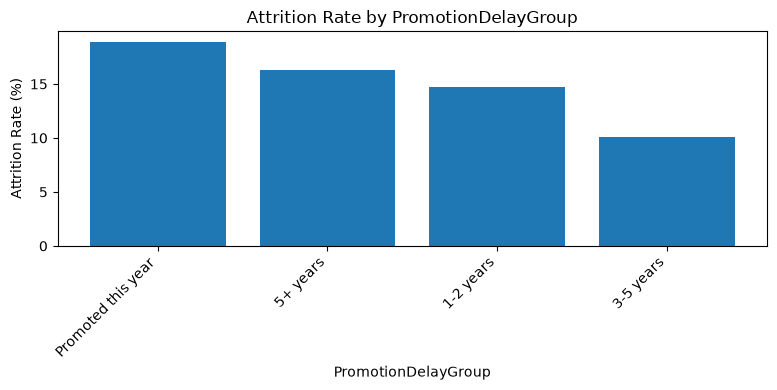

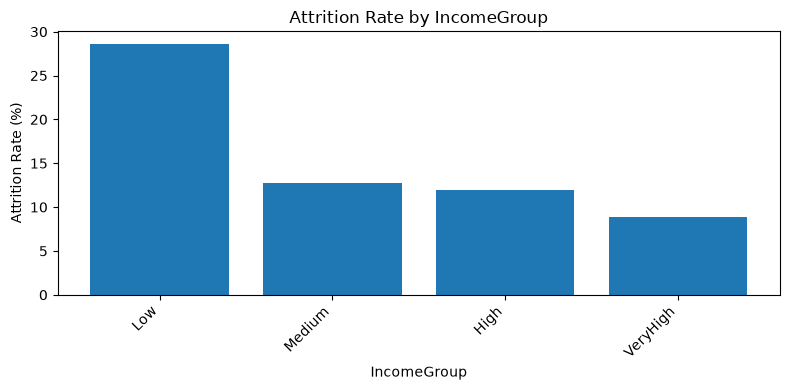

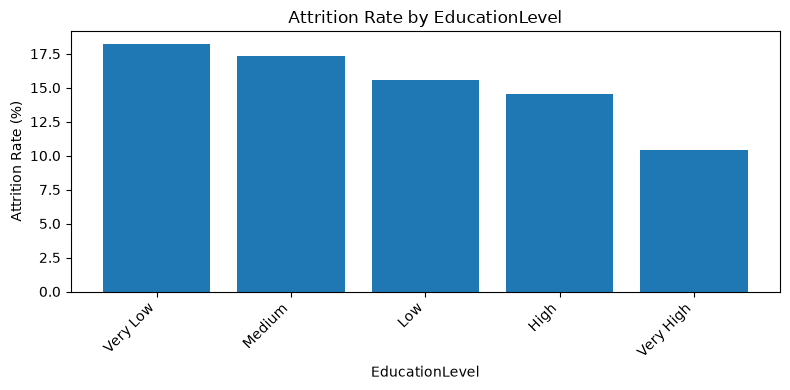

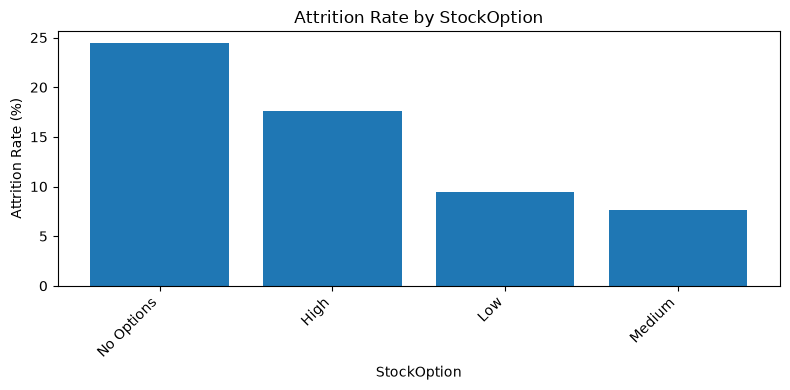

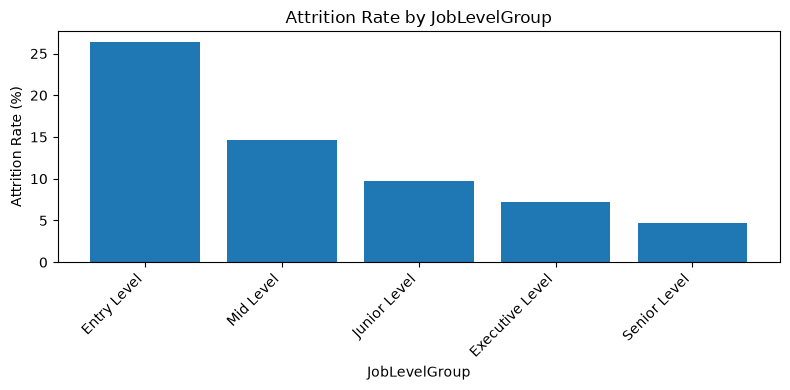

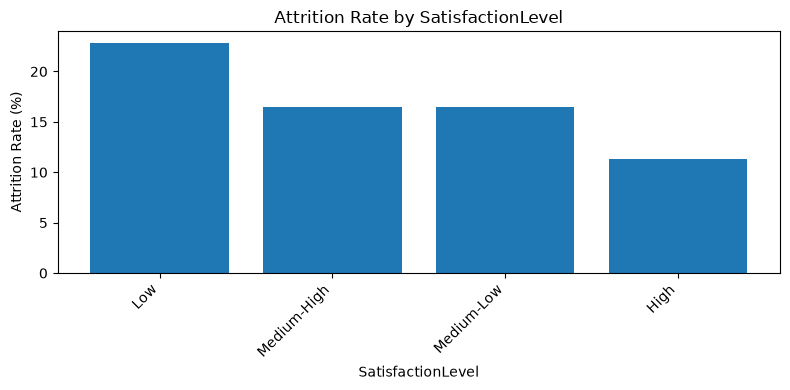

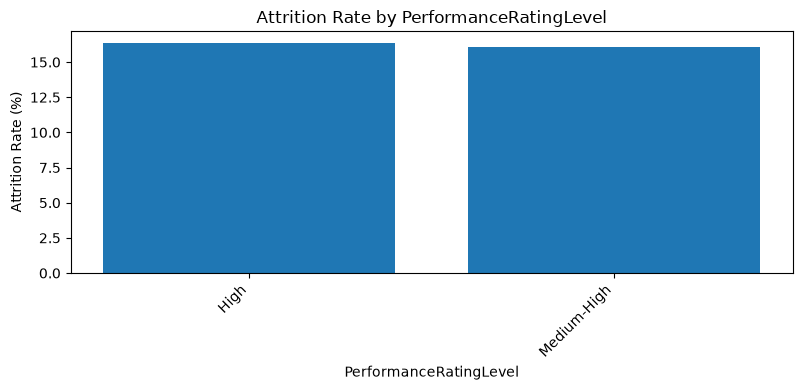

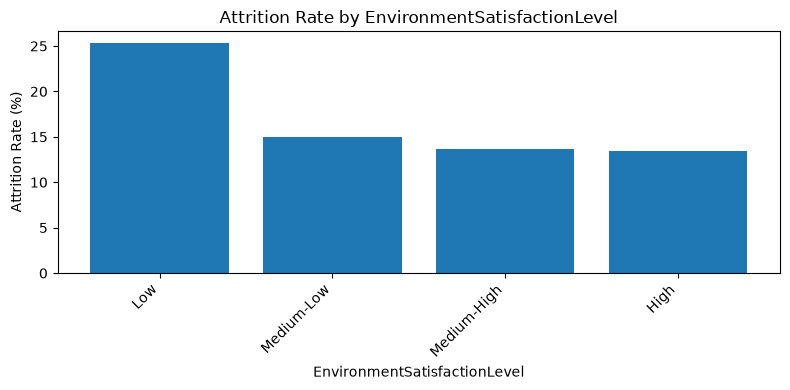

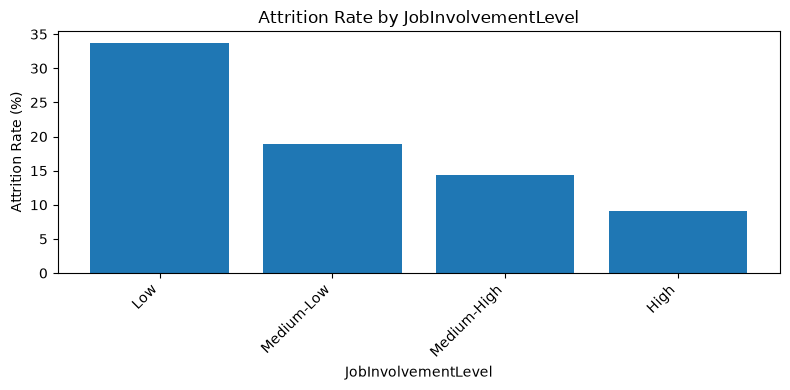

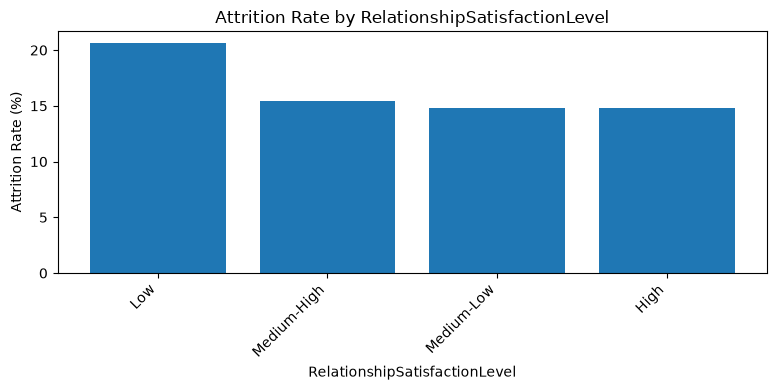

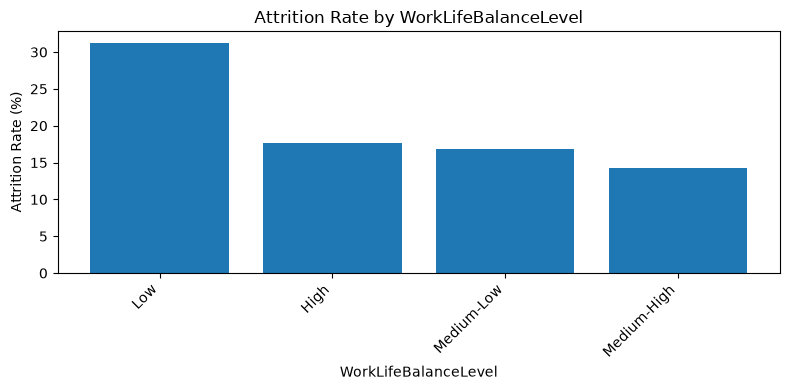

In [ ]:
for col in categorical_vars:
    if col != "Attrition":
        summary = attrition_summary(df, col)

        plt.figure(figsize=(8, 4))
        plt.bar(summary[col], summary["attrition_rate"])

        plt.title(f"Attrition Rate by {col}")
        plt.xlabel(col)
        plt.ylabel("Attrition Rate (%)")

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


# Análises de Correlações e de Colinearidade

In [4]:
print(f'Verificar Pressupostos para o teste do Qui-Quadradro')
display(check_chi_square_assumptions(df, "Attrition"))

print(f'\nTabela do Qui-Quadrado')
display(chi_square_table(df, "Attrition"))
    
print(f'\nTabela de Cramer')
display(cramer_table(df, "Attrition"))

Verificar Pressupostos para o teste do Qui-Quadradro


,Primary_Variable,Secondary_Variable,Rows,Columns,Total_Cells,Cells_Expected_Below_5,Percent_Expected_Below_5,Min_Expected,Assumptions_OK
0,Attrition,EducationField,2,6,12,1,8.33,4.35,Sim
1,Attrition,BusinessTravel,2,3,6,0,0.00,24.18,Sim
2,Attrition,Department,2,3,6,0,0.00,10.16,Sim
3,Attrition,Gender,2,2,4,0,0.00,94.80,Sim
4,Attrition,JobRole,2,9,18,0,0.00,8.38,Sim
5,Attrition,MaritalStatus,2,3,6,0,0.00,52.72,Sim
6,Attrition,OverTime,2,2,4,0,0.00,67.07,Sim
7,Attrition,AgeGroup,2,5,10,0,0.00,7.58,Sim
8,Attrition,TenureGroup,2,5,10,0,0.00,34.66,Sim
9,Attrition,DistanceGroup,2,4,8,0,0.00,32.89,Sim



Tabela do Qui-Quadrado


,Primary_Variable,Secondary_Variable,Chi_square,p_value,Significativo
0,Attrition,CareerStage,88.316,0.0000,Sim
1,Attrition,OverTime,87.564,0.0000,Sim
2,Attrition,JobRole,86.190,0.0000,Sim
3,Attrition,TenureGroup,75.592,0.0000,Sim
4,Attrition,JobLevelGroup,72.529,0.0000,Sim
5,Attrition,IncomeGroup,64.287,0.0000,Sim
6,Attrition,StockOption,60.598,0.0000,Sim
7,Attrition,AgeGroup,59.439,0.0000,Sim
8,Attrition,RoleStabilityGroup,49.451,0.0000,Sim
9,Attrition,MaritalStatus,46.164,0.0000,Sim



Tabela de Cramer


,Primary_Variable,Secondary_Variable,Cramers_V,p_value,Significativo,Association
0,Attrition,CareerStage,0.245,0.0000,Sim,Moderada
1,Attrition,OverTime,0.244,0.0000,Sim,Moderada
2,Attrition,JobRole,0.242,0.0000,Sim,Moderada
3,Attrition,TenureGroup,0.227,0.0000,Sim,Moderada
4,Attrition,JobLevelGroup,0.222,0.0000,Sim,Moderada
5,Attrition,IncomeGroup,0.209,0.0000,Sim,Moderada
6,Attrition,StockOption,0.203,0.0000,Sim,Moderada
7,Attrition,AgeGroup,0.201,0.0000,Sim,Moderada
8,Attrition,RoleStabilityGroup,0.183,0.0000,Sim,Fraca
9,Attrition,MaritalStatus,0.177,0.0000,Sim,Fraca


In [5]:
predictors_cramer_table = categorical_predictors_cramer_table(df, categorical_vars)

display(predictors_cramer_table)

,Variable_1,Variable_2,Cramers_V,p_value,Significativo,Association
0,Department,JobRole,0.939,0.0000,Sim,Forte
1,TenureGroup,RoleStabilityGroup,0.700,0.0000,Sim,Forte
2,IncomeGroup,JobLevelGroup,0.688,0.0000,Sim,Forte
3,JobRole,IncomeGroup,0.607,0.0000,Sim,Forte
4,Department,EducationField,0.590,0.0000,Sim,Forte
...,...,...,...,...,...,...
248,Gender,PerformanceRatingLevel,0.012,0.6473,Não,Muito fraca
249,OverTime,JobInvolvementLevel,0.010,0.9843,Não,Muito fraca
250,Department,OverTime,0.008,0.9543,Não,Muito fraca
251,BusinessTravel,Department,0.008,0.9952,Não,Muito fraca


In [6]:
moderate_or_strong_pairs = predictors_cramer_table[predictors_cramer_table["Cramers_V"] >= 0.20]

display(moderate_or_strong_pairs)

,Variable_1,Variable_2,Cramers_V,p_value,Significativo,Association
0,Department,JobRole,0.939,0.0,Sim,Forte
1,TenureGroup,RoleStabilityGroup,0.700,0.0,Sim,Forte
2,IncomeGroup,JobLevelGroup,0.688,0.0,Sim,Forte
3,JobRole,IncomeGroup,0.607,0.0,Sim,Forte
4,Department,EducationField,0.590,0.0,Sim,Forte
5,MaritalStatus,StockOption,0.583,0.0,Sim,Forte
6,JobRole,JobLevelGroup,0.573,0.0,Sim,Forte
7,CareerStage,IncomeGroup,0.553,0.0,Sim,Forte
8,CareerStage,JobLevelGroup,0.515,0.0,Sim,Forte
9,TenureGroup,CareerStage,0.458,0.0,Sim,Forte


In [7]:
vif_cat_table = vif_categorical_table(df, categorical_vars, target="Attrition")

vif_cat_table[vif_cat_table["VIF"]>5]

,Feature,VIF,Multicollinearity
0,Department_Sales,45.197,Forte
1,Department_Research & Development,44.733,Forte
2,EducationField_Life Sciences,24.568,Forte
3,EducationField_Medical,22.099,Forte
4,JobRole_Sales Executive,14.860,Forte
5,EducationField_Marketing,11.113,Forte
6,EducationField_Technical Degree,9.055,Moderada
7,CareerStage_Late career,8.582,Moderada
8,TenureGroup_6-10,7.814,Moderada
9,JobLevelGroup_Senior Level,7.611,Moderada


# Regressão Logística

In [8]:
categorical_models, categorical_results = run_logistic_models(
    df=df,
    models_vars_dict=CATEGORICAL_MODEL_VARS,
    target="AttritionFlag",
    categorical=True,
    show_summary=False
)

In [9]:
categorical_comparison = compare_logistic_models(categorical_models)

categorical_comparison.round(4)

,Model,N_Observations,Df_Model,Log_Likelihood,LL_Null,LLR_p_value,AIC,BIC,Pseudo_R2
0,Modelo 5 — Estabilidade e Benefícios,1470,24,-491.0335,-649.2914,0.0,1032.0669,1164.3924,0.2437
1,Modelo 6 — Perfil Pessoal,1470,24,-492.1317,-649.2914,0.0,1034.2634,1166.5888,0.2420
2,Modelo 1 — Função Profissional,1470,26,-492.1872,-649.2914,0.0,1038.3744,1181.2859,0.2420
3,Modelo 4 — Trajetória Organizacional,1470,22,-496.8639,-649.2914,0.0,1039.7278,1161.4672,0.2348
4,Modelo 2 — Nível Hierárquico,1470,22,-503.0292,-649.2914,0.0,1052.0584,1173.7978,0.2253
5,Modelo 3 — Faixa Salarial,1470,21,-507.1187,-649.2914,0.0,1058.2374,1174.6838,0.2190
6,Modelo 7 — Reduzido Conservador,1470,18,-542.3755,-649.2914,0.0,1122.7510,1223.3183,0.1647


# Modelo 1 — Função Profissional

Este modelo é focado no papel profissional do funcionário, utilizando `JobRole` como variável principal do bloco. Inclui também variáveis relacionadas às condições de trabalho, satisfação, envolvimento e distância até o trabalho.

**Variáveis do modelo:** `OverTime`, `JobRole`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [10]:
categorical_results["Modelo 1 — Função Profissional"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobRole)[T.Sales Representative],2.7538,15.7016,6.3075,39.0871,0.0000
C(JobInvolvementLevel)[T.Low],1.9719,7.1840,3.1250,16.5150,0.0000
C(JobRole)[T.Laboratory Technician],1.7915,5.9985,2.6689,13.4819,0.0000
C(JobRole)[T.Human Resources],1.7206,5.5878,1.9779,15.7864,0.0012
C(OverTime)[T.Yes],1.7162,5.5635,3.9554,7.8253,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.5286,4.6116,2.2361,9.5104,0.0000
C(JobRole)[T.Sales Executive],1.3289,3.7769,1.6903,8.4393,0.0012
C(SatisfactionLevel)[T.Low],1.1898,3.2863,2.0682,5.2216,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.1672,3.2130,2.0483,5.0400,0.0000
C(JobRole)[T.Research Scientist],1.0900,2.9742,1.3123,6.7404,0.0090


# Modelo 2 — Nível Hierárquico

Este modelo é centrado no nível hierárquico do funcionário, representado por `JobLevelGroup`. O objetivo é avaliar se a posição ocupada na estrutura organizacional contribui para explicar a saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `JobLevelGroup`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [11]:
categorical_results["Modelo 2 — Nível Hierárquico"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobInvolvementLevel)[T.Low],2.1095,8.2438,3.5986,18.8853,0.0000
C(OverTime)[T.Yes],1.6164,5.0348,3.6168,7.0087,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.6100,5.0029,2.3859,10.4903,0.0000
C(SatisfactionLevel)[T.Low],1.1259,3.0829,1.9467,4.8822,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.1138,3.0460,1.9530,4.7508,0.0000
C(JobInvolvementLevel)[T.Medium-Low],1.0694,2.9138,1.4624,5.8055,0.0024
C(BusinessTravel)[T.Travel_Rarely],0.8514,2.3428,1.1692,4.6943,0.0164
C(DistanceGroup)[T.21-30],0.7813,2.1844,1.3675,3.4894,0.0011
C(SatisfactionLevel)[T.Medium-Low],0.7101,2.0341,1.2431,3.3287,0.0047
C(WorkLifeBalanceLevel)[T.Low],0.6889,1.9916,0.9648,4.1111,0.0624


# Modelo 3 — Faixa Salarial

Este modelo é baseado na faixa de remuneração, utilizando `IncomeGroup` como variável principal. Busca verificar se diferenças salariais categorizadas estão associadas à probabilidade de saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `IncomeGroup`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [12]:
categorical_results["Modelo 3 — Faixa Salarial"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobInvolvementLevel)[T.Low],2.1376,8.4794,3.7019,19.4229,0.0000
C(OverTime)[T.Yes],1.6343,5.1258,3.6820,7.1357,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.5873,4.8905,2.3573,10.1459,0.0000
C(SatisfactionLevel)[T.Low],1.2104,3.3548,2.1209,5.3066,0.0000
C(IncomeGroup)[T.Low],1.1965,3.3085,2.0722,5.2826,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.1487,3.1542,2.0246,4.9140,0.0000
C(JobInvolvementLevel)[T.Medium-Low],1.1304,3.0969,1.5559,6.1642,0.0013
C(BusinessTravel)[T.Travel_Rarely],0.8669,2.3795,1.1992,4.7217,0.0132
C(WorkLifeBalanceLevel)[T.Low],0.7444,2.1052,1.0227,4.3333,0.0433
C(JobInvolvementLevel)[T.Medium-High],0.7180,2.0503,1.0651,3.9468,0.0316


# Modelo 4 — Trajetória Organizacional

Este modelo é voltado ao estágio de carreira do funcionário, representado por `CareerStage`. O objetivo é analisar se diferentes momentos da trajetória profissional apresentam padrões distintos de saída.

**Variáveis do modelo:** `OverTime`, `CareerStage`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [13]:
categorical_results["Modelo 4 — Trajetória Organizacional"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobInvolvementLevel)[T.Low],2.1015,8.1782,3.5416,18.8850,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.7247,5.6107,2.6904,11.7011,0.0000
C(OverTime)[T.Yes],1.6874,5.4052,3.8628,7.5634,0.0000
C(CareerStage)[T.Entry-level],1.5824,4.8665,2.7018,8.7658,0.0000
C(SatisfactionLevel)[T.Low],1.2530,3.5007,2.1963,5.5799,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.2312,3.4254,2.1838,5.3729,0.0000
C(JobInvolvementLevel)[T.Medium-Low],1.0561,2.8751,1.4333,5.7675,0.0029
C(BusinessTravel)[T.Travel_Rarely],0.9600,2.6118,1.3130,5.1954,0.0062
C(WorkLifeBalanceLevel)[T.Low],0.8115,2.2512,1.0842,4.6744,0.0295
C(JobInvolvementLevel)[T.Medium-High],0.7047,2.0233,1.0449,3.9180,0.0366


# Modelo 5 — Estabilidade e Benefícios

Este modelo combina estabilidade na função e benefícios, por meio de `RoleStabilityGroup` e `StockOption`. Procura avaliar se o tempo na função e a existência de stock options ajudam a explicar a permanência ou saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `RoleStabilityGroup`, `StockOption`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [14]:
categorical_results["Modelo 5 — Estabilidade e Benefícios"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobInvolvementLevel)[T.Low],2.1632,8.6992,3.7132,20.3803,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.6946,5.4442,2.5703,11.5318,0.0000
C(OverTime)[T.Yes],1.5735,4.8237,3.4560,6.7325,0.0000
C(SatisfactionLevel)[T.Low],1.1602,3.1906,2.0028,5.0829,0.0000
C(JobInvolvementLevel)[T.Medium-Low],1.0765,2.9343,1.4474,5.9485,0.0028
C(EnvironmentSatisfactionLevel)[T.Low],0.9904,2.6924,1.7196,4.2155,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.9046,2.4710,1.2244,4.9868,0.0116
C(DistanceGroup)[T.21-30],0.7584,2.1349,1.3189,3.4558,0.0020
C(WorkLifeBalanceLevel)[T.Low],0.7555,2.1286,1.0145,4.4661,0.0457
C(JobInvolvementLevel)[T.Medium-High],0.7309,2.0769,1.0586,4.0745,0.0335


# Modelo 6 — Perfil Pessoal

Este modelo incorpora características pessoais e sociodemográficas, como `AgeGroup` e `MaritalStatus`, juntamente com variáveis de trabalho e satisfação. Busca observar se o perfil individual contribui para a explicação da saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `AgeGroup`, `MaritalStatus`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [15]:
categorical_results["Modelo 6 — Perfil Pessoal"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobInvolvementLevel)[T.Low],2.1468,8.5573,3.6829,19.8828,0.0000
C(OverTime)[T.Yes],1.6994,5.4708,3.8973,7.6795,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.6180,5.0432,2.3971,10.6104,0.0000
C(SatisfactionLevel)[T.Low],1.2275,3.4126,2.1418,5.4373,0.0000
C(MaritalStatus)[T.Single],1.1786,3.2498,2.0271,5.2098,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.1445,3.1410,2.0015,4.9292,0.0000
C(JobInvolvementLevel)[T.Medium-Low],1.0392,2.8271,1.4065,5.6824,0.0035
C(WorkLifeBalanceLevel)[T.Low],0.8866,2.4269,1.1678,5.0436,0.0175
C(BusinessTravel)[T.Travel_Rarely],0.8448,2.3276,1.1615,4.6646,0.0172
C(SatisfactionLevel)[T.Medium-Low],0.8003,2.2262,1.3464,3.6808,0.0018


# Modelo 7 — Reduzido Conservador

Este modelo é uma versão mais simples e conservadora, formada apenas por variáveis gerais de trabalho, satisfação e deslocamento. Serve como referência para comparação com os modelos que incluem blocos categóricos mais específicos.

**Variáveis do modelo:** `OverTime`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [16]:
categorical_results["Modelo 7 — Reduzido Conservador"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobInvolvementLevel)[T.Low],2.0239,7.5680,3.3911,16.8900,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.5784,4.8472,2.3959,9.8063,0.0000
C(OverTime)[T.Yes],1.5509,4.7157,3.4380,6.4682,0.0000
C(SatisfactionLevel)[T.Low],1.1066,3.0239,1.9433,4.7056,0.0000
C(JobInvolvementLevel)[T.Medium-Low],1.0619,2.8918,1.4750,5.6692,0.0020
C(EnvironmentSatisfactionLevel)[T.Low],1.0499,2.8574,1.8714,4.3629,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.8690,2.3846,1.2294,4.6250,0.0101
C(WorkLifeBalanceLevel)[T.Low],0.7274,2.0697,1.0404,4.1175,0.0382
C(SatisfactionLevel)[T.Medium-Low],0.7061,2.0261,1.2633,3.2496,0.0034
C(JobInvolvementLevel)[T.Medium-High],0.6382,1.8931,0.9947,3.6029,0.0519
